<a href="https://colab.research.google.com/github/shohinirheasarkar/imc-prosperity-4-daily-tracker/blob/main/eda/exploringtutorialdataimc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Necessary Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load in the data

In [2]:
prices_day1 = pd.read_csv("prices_round_0_day_-1.csv", sep=";")
prices_day2 = pd.read_csv("prices_round_0_day_-2.csv", sep=";")

trades_day1 = pd.read_csv("trades_round_0_day_-1.csv", sep=";")
trades_day2 = pd.read_csv("trades_round_0_day_-2.csv", sep=";")

Take a look at the data

In [3]:
prices_day1.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


Definitions


*   bid_price_1: the highest price someone is willing to buy an item
*   bid_volume_1: how much of the item they want
*   ask_price_1: the lowest price someone is willing to sell at
*  ask_volume_1: how much of the item they are willing to sell






Combine Data & Separate by Product

In [4]:
# combine both days
prices = pd.concat([prices_day1, prices_day2], ignore_index=True)

# separate by product
tomatoes = prices[prices["product"] == "TOMATOES"].copy()
emeralds = prices[prices["product"] == "EMERALDS"].copy()

print(f"Tomatoes rows: {len(tomatoes)}")
print(f"Emeralds rows: {len(emeralds)}")

Tomatoes rows: 20000
Emeralds rows: 20000


Mid prices over time

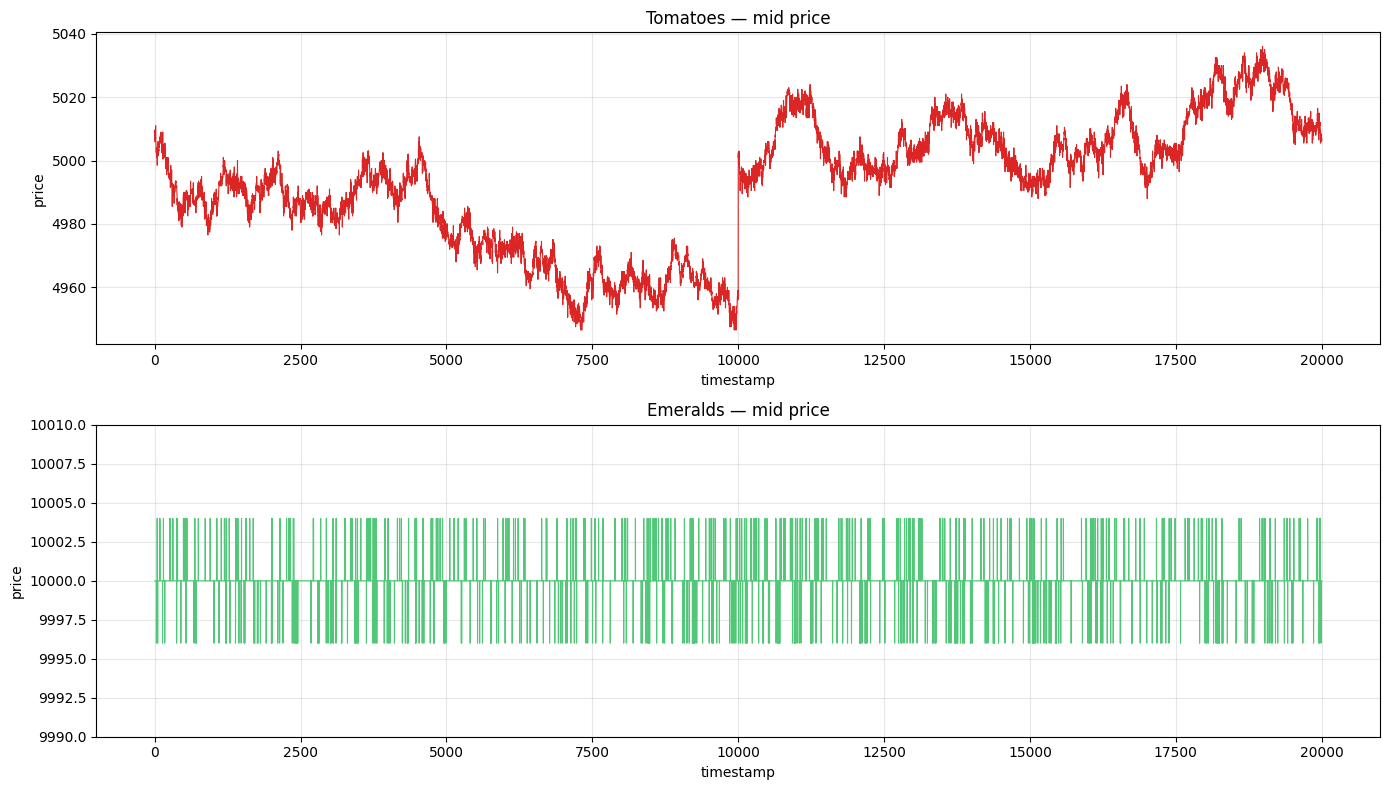

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# tomatoes
axes[0].plot(tomatoes["mid_price"].values, linewidth=0.8, color="#dc2626")
axes[0].set_title("Tomatoes — mid price")
axes[0].set_xlabel("timestamp")
axes[0].set_ylabel("price")
axes[0].grid(True, alpha=0.3)

# emeralds — zoom in on the y axis so the 3 price levels are visible
axes[1].plot(emeralds["mid_price"].values, linewidth=0.8, color="#50C878")
axes[1].set_title("Emeralds — mid price")
axes[1].set_xlabel("timestamp")
axes[1].set_ylabel("price")
axes[1].set_ylim(9990, 10010)  # zoom in — we know values are 9996, 10000, 10004
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rolling Mean Overlay

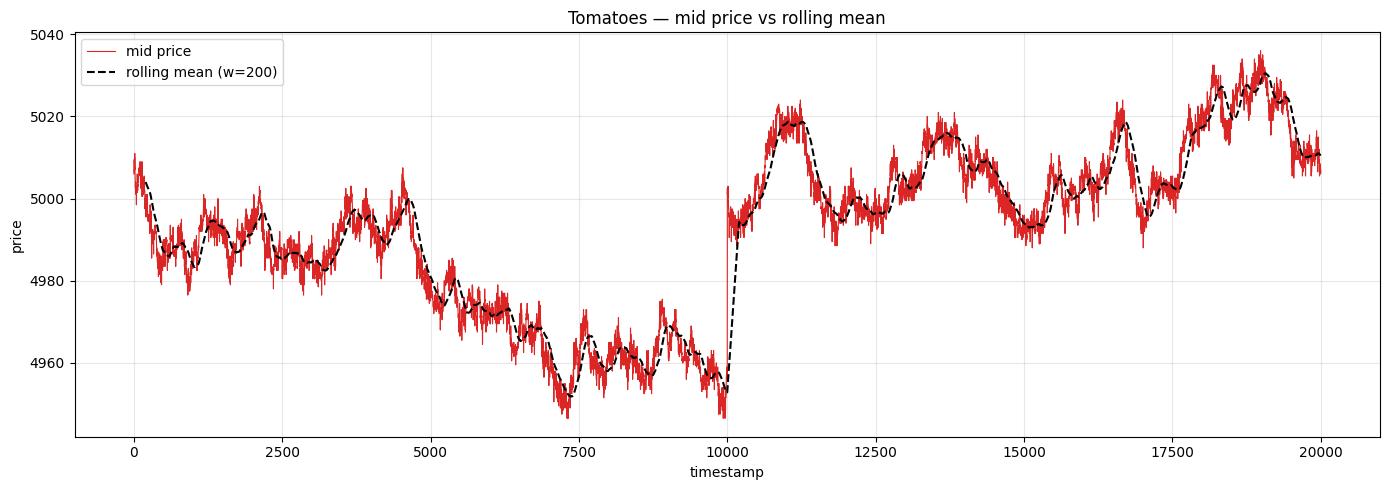

In [10]:
window = 200

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tomatoes["mid_price"].values, linewidth=0.8, color="#dc2626", label="mid price")
ax.plot(pd.Series(tomatoes["mid_price"].values).rolling(window).mean(),
        linewidth=1.5, color="black", linestyle="--", label=f"rolling mean (w={window})")

ax.set_title("Tomatoes — mid price vs rolling mean")
ax.set_xlabel("timestamp")
ax.set_ylabel("price")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Deviation from Rolling Mean

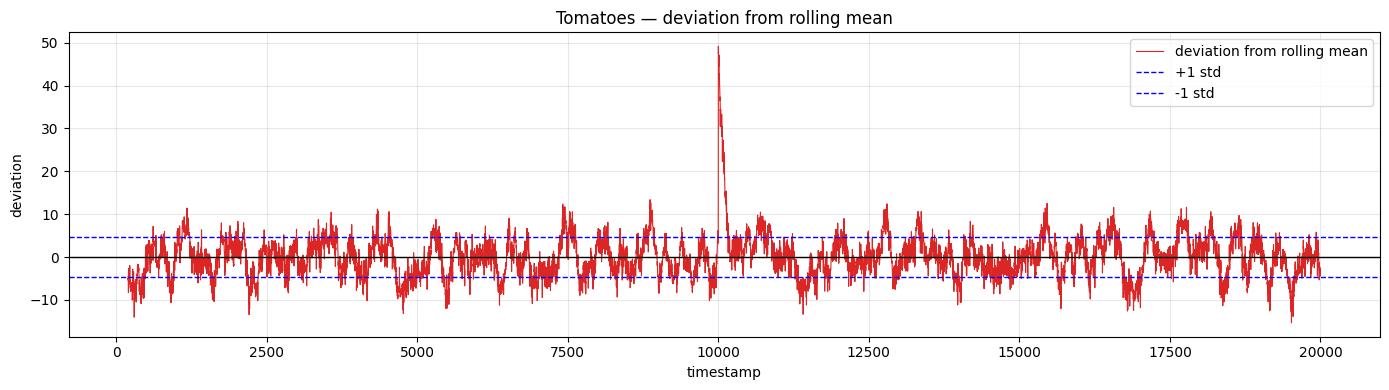

In [11]:
window = 200

rolling_mean = pd.Series(tomatoes["mid_price"].values).rolling(window).mean()
deviation = tomatoes["mid_price"].values - rolling_mean

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(deviation, linewidth=0.8, color="#dc2626", label="deviation from rolling mean")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(deviation.std(), color="blue", linestyle="--", linewidth=1, label=f"+1 std")
ax.axhline(-deviation.std(), color="blue", linestyle="--", linewidth=1, label=f"-1 std")

ax.set_title("Tomatoes — deviation from rolling mean")
ax.set_xlabel("timestamp")
ax.set_ylabel("deviation")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
window = 200
rolling_mean = pd.Series(tomatoes["mid_price"].values).rolling(window).mean()
deviation = tomatoes["mid_price"].values - rolling_mean

print(f"deviation std:  {deviation.std():.4f}")
print(f"deviation mean: {deviation.mean():.4f}")
print(f"deviation max:  {deviation.max():.4f}")
print(f"deviation min:  {deviation.min():.4f}")

deviation std:  4.7614
deviation mean: 0.0334
deviation max:  49.1975
deviation min:  -15.3625
